# Конструирование функций выбора лучших точек

In [3]:
import random

import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

from genesis.core import BestPointsBase, MetricBase, StateBase, StopCaseBase, LSCPBase, PointSelectorBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.mclp import BestNodesKoptG
from genesis.tools import list_dict_concat, get_dict_key
from genesis.utils import timing
from genesis.swiss_knife import CMAP_GrGldRd


In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

# Конструирование

## Простой случайный выбор

<Axes: >

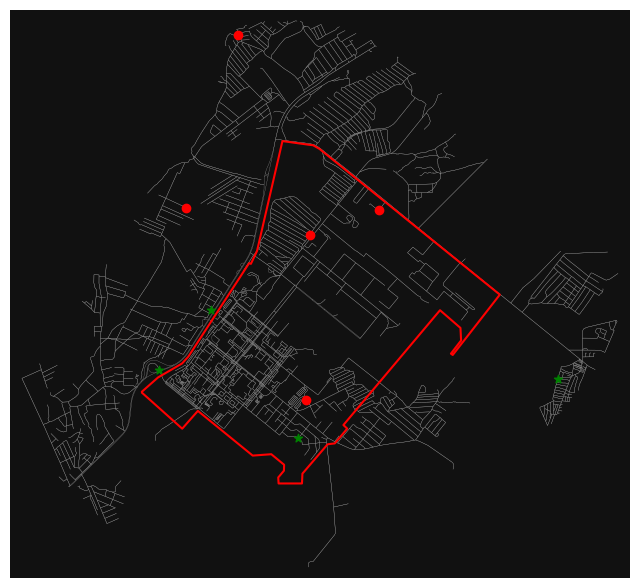

In [41]:
class RandomNodesSelector(PointSelectorBase):
    '''
    Простой выбор случайного узла в графе
    '''
    def __init__(self, **kwargs) -> None:
        '''
        Простой выбор случайного узла в графе
        '''
        super().__init__(**kwargs)

    def __call__(self,
                env:nx.MultiDiGraph,
                points:dict,
                area: pd.Series = None,
                k:int = 1,
                **kwargs):
        '''
        Запуск работы алгоритма

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `points`: dict
            Список стартовых узлов графа в которых размещены
            подразделения.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        `k`: int = 1
            Количество подразделений которые следует добавить.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
        if not isinstance(points,dict):
            raise TypeError(f'Аргумент `points` должен иметь тип: dict'
                            f'Имеет: {type(points)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')
        if k < 1:
            raise ValueError(f'Аргумент `k` должен быть >= 1! Имеет: {k}')

        # 1. Выбор случайных n узлов из числа не входящих в points
        points_set = set(points.keys())
        if area is None:
            nodes_set = set(env.nodes()) - points_set
        else:
            nodes_set = set(env.nodes()) & set(area[area].keys()) - points_set
        new_nodes = random.choices(list(nodes_set), k=k)

        return new_nodes

nodes = list(G.nodes())
all_units = {
    nodes[100]:'A',
    nodes[2000]:'B',
    nodes[3000]:'C',
    nodes[4000]:'D',
}

g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)
points_mask = g_nodes_gdf.within(area.iloc[0].geometry)


new_nodes = RandomNodesSelector()(G, all_units, k=5)
# new_nodes = RandomNodesSelector()(G, all_units, k=5, area=points_mask)

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[all_units.keys()].plot(ax=ax, c='g', marker='*')
g_nodes_gdf.loc[new_nodes].plot(ax=ax, c='r')
area.boundary.plot(ax=ax, color='r')


## Как в Генезис 2022

In [72]:
# class GenesisNodeSelector(PointSelectorBase):
#     '''
#     Простой выбор случайного узла в графе
#     '''
#     def __init__(self,
#                  state_function: StateBase,
#                  metric_function: MetricBase,
#                  appr_val: float = 0.95,
#                  weight='travel_time',
#                  **kwargs) -> None:
#         '''
#         ## Аргументы
#         `state_algorithm`: function
#             Функция расчета кратчайших путей от единственного источника. 
#             В качестве функции могут быть переданы реализации алгоритмов из пакета
#             `networkx`. Например, реализация алгоритма Дейкстры: `nx.multi_source_dijkstra`.
#             Пользователь может использовать собственные функции с
#             интерфейсом `func(G: Graph, sources: Any, target: Any | None = None, cutoff: Any | None = None, 
#             weight: str = "weight") -> (dict, dict)`
#         `state_function`: StateBase
#             функция расчета состояния окружения
#         `appr_val`: = 0.95
#             Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики. 
#             Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
#             то такой узел не рассматривается.
#         `weight`:str или function  = "travel_time"
#             Имя поля содержащего вес ребер, или функция позволяющая вычислять 
#             вес динамически.
#         '''
#         # self.state_algorithm = state_algorithm
#         self.state_function = state_function
#         self.metric_function = metric_function
#         self.appr_val = appr_val
#         self.weight = weight
#         super().__init__(**kwargs)

#     def __call__(self,
#                 env:nx.MultiDiGraph,
#                 points:dict,
#                 area: pd.Series = None,
#                 **kwargs):
#         '''
#         Запуск работы алгоритма

#         ## Аргументы
#         `env`:nx.MultiDiGraph
#             Граф улично-дорожной сети
#         `points`: dict
#             Список стартовых узлов графа в которых размещены
#             подразделения.
#         `area`: pd.Series = None
#             Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
#             Если не указана, расчет производится для всех узлов графа.
#         '''

#         # 1. Расчет состояния прибытия
#         times, nearest = self.state_function(env = env,
#                                              points = points,
#                                              area = area,
#                                              **kwargs)

#         # nx.set_node_attributes(env, pd.Series(nearest, dtype=str), 'nearest')
#         # nds = ox.graph_to_gdfs(env, edges=False)
#         # fig, ax = ox.plot_graph(env, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
#         # nds.plot(ax=ax, markersize=2, column='nearest', cmap='Set3', legend=True)
#         # nds.loc[list(points.keys())].plot(ax=ax, markersize=25, color='red', marker="*")
#         # fig.show()

#         # 2. Группировка по деревьям Вороного
#         # и вычисление наихудшего из них
#         worst_unit_id = None
#         worst_unit_metric = None
#         for unit_id in nearest.unique():
#             unit_area_nodes = nearest[nearest == unit_id].index.tolist()
#             unit_times = times[unit_area_nodes]
#             unit_metric = self.metric_function(unit_times)

#             print(unit_id, unit_metric)

#             if worst_unit_id is None:
#                 worst_unit_id = unit_id
#                 worst_unit_metric = unit_metric
#             else:
#                 if self.metric_function.compare(worst_unit_metric, unit_metric) == worst_unit_metric:
#                     worst_unit_id = unit_id
#                     worst_unit_metric = unit_metric

#             print("Выбрано:", worst_unit_id, worst_unit_metric)

#         print("="*80)
#         # 3. Поиск наихудшего узла соседнего с наихудшим узлом
#         worst_unit_node = get_dict_key(points, worst_unit_id)
#         worst_node = None
#         worst_node_metric = None
#         for node in env[worst_unit_node]:
#             times, nearest = self.state_function(env = env,
#                                              points = [worst_unit_node, node],
#                                              area = area,
#                                              **kwargs)
#             node_metric = self.metric_function(times)
#             print(node, node_metric)

#             if worst_node is None:
#                 worst_node = node
#                 worst_node_metric = node_metric
#             else:
#                 if self.metric_function.compare(worst_node_metric, node_metric) == node_metric:
#                     worst_node = node
#                     worst_node_metric = node_metric

#             print("Выбрано:", worst_node, worst_node_metric)

#         return worst_node




from genesis.point_selectors import GenesisNodeSelector


nodes = list(G.nodes())
all_units = {
    nodes[100]:'A',
    nodes[2000]:'B',
    nodes[3000]:'C',
    nodes[4000]:'D',
}

g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)
points_mask = g_nodes_gdf.within(area.iloc[0].geometry)


# new_node = GenesisNodeSelector(FirstArrivalUnitState(), ArrivalTime())(G, all_units)
new_node = GenesisNodeSelector(FirstArrivalUnitState(), CoverIndex())(G, all_units)
# new_node = GenesisNodeSelector(FirstArrivalUnitState(), ArrivalTime())(G, all_units, area=points_mask)


new_node

A 71.83673469387755
Выбрано: A 71.83673469387755
B 45.23227383863081
Выбрано: B 45.23227383863081
C 100.0
Выбрано: B 45.23227383863081
D 100.0
Выбрано: B 45.23227383863081
2042076753 10.101744186046512
Выбрано: 2042076753 10.101744186046512
2042076739 10.08357558139535
Выбрано: 2042076753 10.101744186046512
2042076746 10.08357558139535
Выбрано: 2042076753 10.101744186046512


2042076753

<Axes: >

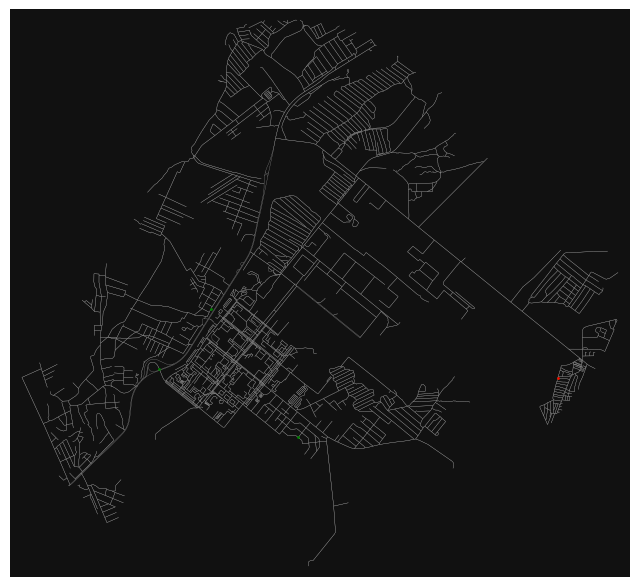

In [71]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[all_units.keys()].plot(ax=ax, c='g', markersize=1)
g_nodes_gdf.loc[[new_node]].plot(ax=ax, c='r', markersize=1)

## Худший узел

In [32]:
# class WorstNodeSelector(PointSelectorBase):
#     '''
#     Выбор узла с наихудшей метрикой, 
#     (?) из которого при этом можно попасть
#     в большую часть графа
#     '''
#     def __init__(self,
#                  state_function: StateBase,
#                  metric_function: MetricBase,
#                  appr_val: float = 0.5,
#                  weight='travel_time',
#                  **kwargs) -> None:
#         '''
#         ## Аргументы
#         `state_function`: StateBase
#             функция расчета состояния окружения
#         `metric_function`: MetricBase
#             Функция расчета метрики
#         `appr_val`: = 0.5
#             Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики. 
#             Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
#             то такой узел не рассматривается.
#         `weight`:str или callable  = "travel_time"
#             Имя поля содержащего вес ребер, или функция позволяющая вычислять 
#             вес динамически.
#         '''
#         self.state_function = state_function
#         self.metric_function = metric_function
#         self.appr_val = appr_val
#         self.weight = weight
#         super().__init__(**kwargs)

#     def __call__(self,
#                 env:nx.MultiDiGraph,
#                 points:dict,
#                 area: pd.Series = None,
#                 **kwargs):
#         '''
#         Запуск работы алгоритма

#         ## Аргументы
#         `env`:nx.MultiDiGraph
#             Граф улично-дорожной сети
#         `points`: dict
#             Список стартовых узлов графа в которых размещены
#             подразделения.
#         `area`: pd.Series = None
#             Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
#             Если не указана, расчет производится для всех узлов графа.
#         '''

#         # 0. Проверка корректности пришедших данных
#         if not isinstance(env, nx.MultiDiGraph):
#             raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
#         if not isinstance(points,dict):
#             raise TypeError(f'Аргумент `points` должен иметь тип: dict'
#                             f'Имеет: {type(points)}')
#         if not area is None and not isinstance(area, pd.Series):
#             raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

#         # 1. Расчет состояния прибытия
#         times, nearest = self.state_function(env = env,
#                                              points = points,
#                                              area = area,
#                                              **kwargs)

#         # 2. Сортировка узлов по времени прибытия
#         times = times.sort_values(ascending=False)

#         # 3. Последовательный перебор наихудших узлов и оценка достижимости из каждого из них
#         # 3.1. Определение количества допустимых узлов
#         # ... Тут нужно подумать ...
#         if area is None:
#             appr_nodes_count = int(env.number_of_nodes()*self.appr_val)
#         else:
#             appr_nodes_count = int(area.sum()*self.appr_val)
#         # 3.2. Перебор узлов
#         for node in times.index:
#             node_times, _ = self.state_function(env = env,
#                                                 points = [node],
#                                                 area = area,
#                                                 **kwargs)
#             print(node, len(node_times), appr_nodes_count)
#             if len(node_times) >= appr_nodes_count:
#                 return node

#         # 4. Если по какой-то причине ни один узел не был найден вызываем ошибку
#         raise LookupError('Не удалось найти ни одного узла')


# ==============================================
from genesis.point_selectors import WorstNodeSelector


nodes = list(G.nodes())
all_units = {
    nodes[1000]:'A',
    nodes[2000]:'B',
    nodes[3000]:'C',
    nodes[4000]:'D',
}

g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)
points_mask = g_nodes_gdf.within(area.iloc[0].geometry)


new_node1 = WorstNodeSelector(FirstArrivalUnitState(), ArrivalTime())(G, all_units)
new_node2 = WorstNodeSelector(FirstArrivalUnitState(), ArrivalTime(np.max))(G, all_units)
new_node3 = WorstNodeSelector(FirstArrivalUnitState(), CoverIndex(5))(G, all_units)
new_node4 = WorstNodeSelector(FirstArrivalUnitState(), ArrivalTime())(G, all_units, area=points_mask)


new_node1, new_node2, new_node3, new_node4

10816267941 5504 2757
10816267941 5504 2757
10816267941 5504 2757
4116025605 2237 1120


(10816267941, 10816267941, 10816267941, 4116025605)

C:\Users\Obsidian\AppData\Local\Temp\ipykernel_37700\851825307.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


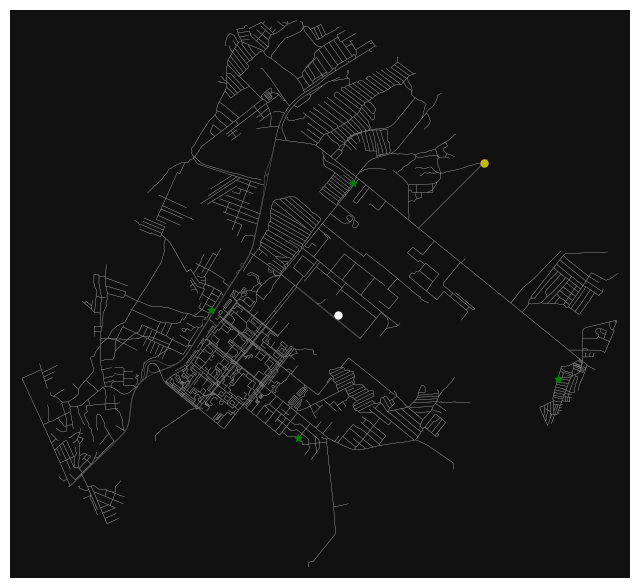

In [33]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[all_units.keys()].plot(ax=ax, c='g', markersize=25, marker="*")
g_nodes_gdf.loc[[new_node1]].plot(ax=ax, c='r', markersize=25)
g_nodes_gdf.loc[[new_node2]].plot(ax=ax, c='b', markersize=25)
g_nodes_gdf.loc[[new_node3]].plot(ax=ax, c='y', markersize=25)
g_nodes_gdf.loc[[new_node4]].plot(ax=ax, c='w', markersize=25)

fig.show()

In [17]:
nodes = list(G.nodes())
all_units = {
    nodes[100]:'A',
    nodes[2000]:'B',
    nodes[3000]:'C',
    nodes[4000]:'D',
}

g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)
points_mask = g_nodes_gdf.within(area.iloc[0].geometry)



# 1. Расчет состояния прибытия
times, nearest = FirstArrivalUnitState()(env = G,
                                        points = all_units,
                                        # area = points_mask,
                                        )
print(times.head(3))

# 2. Сортировка узлов по времени прибытия
times = times.sort_values(ascending=False)
print(times.head(3))

# 
appr_val=0.95
appr_nodes_count = int(G.number_of_nodes()*appr_val)
i=0
for node in times.index:
    node_times, _ = FirstArrivalUnitState()(env = G,
                                        points = [node],
                                        # area = points_mask,
                                        )
    if len(node_times) >= appr_nodes_count:
        print(node, len(node_times), appr_nodes_count)
    # if len(node_times) < appr_nodes_count:
    #     print(i, node, len(node_times), 'из', G.number_of_nodes())
    # else:
    #     print(i, end='\r')
    # i+=1

1296599762    1.0
2042076750    1.0
2760591335    1.0
Name: times, dtype: float64
10816268041    23.958373
10816268040    23.609989
10816268039    23.364625
Name: times, dtype: float64
10816268041 5504 5238
10816268040 5504 5238
10816268039 5504 5238
10816268038 5504 5238
10816268037 5504 5238
10816267941 5504 5238
10816268036 5504 5238
10816267940 5504 5238
10816268035 5504 5238
10816267939 5504 5238
10816268027 5504 5238
10816268034 5504 5238
10816268026 5504 5238
10816268028 5504 5238
10816268025 5504 5238
10816267938 5504 5238
10816268024 5504 5238
10816268033 5504 5238
10816268023 5504 5238
10816267937 5504 5238
10816268022 5504 5238
10816268012 5504 5238
10816268032 5504 5238
10816268021 5504 5238
10816268013 5504 5238
10816268020 5504 5238
10816267936 5504 5238
10816268031 5504 5238
10816268014 5504 5238
10816267965 5504 5238
10816268019 5504 5238
10816268030 5504 5238
10816267964 5504 5238
10816267966 5504 5238
10816268015 5504 5238
10816268018 5504 5238
10816267994 5504 5238
1

KeyboardInterrupt: 